# Free oscillations: the Earth's normal modes from the same matrices

Notebook 3 assembled the operator with `A, _, ops, ns, jr = assemble_planet(...)` and then *forced*
it — solved the static `A y = f` for the tidal response, and read Love numbers and compliances off it
(NB3–4). But that call returned a second matrix we quietly threw away with the `_`: the **mass matrix
`B`** (the inertia `ρω²` term). Restore it and the static problem becomes an **eigenproblem**,

$$A\,x = \omega^2\,B\,x,$$

whose solutions are the Earth's **free oscillations** — the spheroidal normal modes. Same assembly,
same `A`; we just stop ignoring `B`. `free_modes(m)` does exactly this; here we compute PREM's
$_nS_2$ modes and check their periods against MINEOS.

In [9]:
using Pkg; Pkg.activate(@__DIR__)
using Melinoe, ApproxFun, PyPlot, Printf

# Modes want the AW core (N² = 0, no spurious g-modes) + anelastic dispersion (matches MINEOS-PREM).
# Both are opt-in now — PREM() on its own is the raw tabulated, elastic model.
m = Melinoe.Models.PREM(use_aw_oc = true, anelastic = true)

  Activating project at `~/code/ge-julia/examples`


PlanetModel("PREM", 12 layers, R=6371.0 km, ρ̄=5515.0 kg/m³)

## 1 · From forcing to free oscillation

Static problems (Love numbers, compliances) set `ω² = 0`, so `B` drops out and you solve `A y = f`.
A free mode is the opposite — no forcing, `ω² ≠ 0` — the eigenpairs of `A x = ω² B x`. `free_modes(m)`
assembles `A, B` and solves that generalized eigenproblem directly. `B` is *singular*: self-gravity is
instantaneous, so Poisson carries no time derivative and the whole `δφ` row and column of `B` vanish.
QZ copes with that, and the spurious eigenvalues it returns for the null directions are filtered out.
The survivors are `ω²`, and the $_nS_2$ periods follow. Because `ω² ≠ 0` the fluid outer core is now
**dynamic**, so — unlike NB4's static compliances — no `dahlenize` is needed.

In [10]:
fm = free_modes(m)
mineos = [53.89, 24.52, 17.77, 15.07, 9.68, 7.97, 6.91, 6.62]   # ₙS₂ periods (min), MINEOS-PREM
@printf("Spheroidal modes ₙS₂ vs MINEOS-PREM:\n")
@printf("   n    model (min)   MINEOS (min)      Δ\n")
for (n, Tref) in enumerate(mineos)
    n > length(fm.T_min) && break
    @printf("   %d   %10.3f    %10.2f      %+.2f%%\n", n-1, fm.T_min[n], Tref, 100*(fm.T_min[n]-Tref)/Tref)
end

Spheroidal modes ₙS₂ vs MINEOS-PREM:
   n    model (min)   MINEOS (min)      Δ
   0       53.975         53.89      +0.16%
   1       24.618         24.52      +0.40%
   2       18.005         17.77      +1.32%
   3       15.121         15.07      +0.34%
   4        9.710          9.68      +0.31%
   5        8.014          7.97      +0.55%
   6        7.032          6.91      +1.76%
   7        6.653          6.62      +0.50%


## 2 · What a mode looks like

Each eigenvalue carries an eigenvector — the mode's displacement field. `fm.vs` holds them in the full
`(U, V, δφ)` basis, so `fm.recover` is just `identity`; we pull the radial part `U(r)` of the
fundamental **$_0S_2$** (the longest-period mode, ~54 min). Reconstructing it uses the *same*
`Fun(ops[i].S, …)` trick as NB3 — the eigenvector entries **are** the per-layer Chebyshev coefficients.

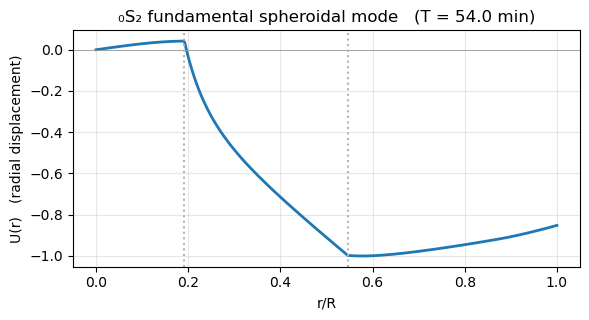

In [8]:
_, _, ops, ns = assemble_planet(m.layers, 2)         # same assembly; grab ops/ns to rebuild the field
Ntot = sum(ns); cumN = cumsum([0; ns])
y  = fm.recover(fm.vs[:, fm.sorted_idx[1]])          # fundamental ₀S₂ → full (U, V, δφ) coefficients
Uc = real(y[1:Ntot]); Uc ./= maximum(abs, Uc)        # U-field coefficients, normalised
Ufun = [Fun(ops[i].S, Uc[cumN[i]+1:cumN[i+1]]) for i in eachindex(ns)]
Ur(r) = (for i in eachindex(ns); r ≤ rightendpoint(m.layers[i].domain)+1e-9 && return Ufun[i](r); end)

rr = range(1e-4, 1, length = 500)
fig, ax = subplots(figsize = (6, 3.3))
ax.plot(rr, Ur.(rr), lw = 2)
ax.axhline(0, color = "0.6", lw = 0.6)
for x in (1221.5/6371, 3480/6371); ax.axvline(x, color = "0.7", ls = ":"); end
ax.set_xlabel("r/R"); ax.set_ylabel("U(r)   (radial displacement)"); ax.grid(alpha = 0.3)
ax.set_title("₀S₂ fundamental spheroidal mode   (T = $(round(fm.T_min[1], digits = 1)) min)")
tight_layout(); gcf()